In [1]:
# dataset: https://www.kaggle.com/datasets/milanzdravkovic/pharma-sales-data

In [64]:
import pandas as pd
import plotly.express as px

In [ ]:
Sales_monthly = pd.read_csv('salesmonthly.csv')
Sales_weekly = pd.read_csv('salesweekly.csv')
Sales_daily = pd.read_csv('salesdaily.csv')
Sales_hourly = pd.read_csv('saleshourly.csv')

# Finding the peak hour & Recession

In [194]:
Sales_hourly

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.00,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.00,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.00,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.00,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.00,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
50527,10/8/2019 15:00,0.00,0.40,0.0,11.3,1.0,0.0,0.0,0.0,2019,10,15,Tuesday
50528,10/8/2019 16:00,0.33,0.00,0.0,1.0,2.0,0.0,0.0,0.0,2019,10,16,Tuesday
50529,10/8/2019 17:00,0.00,0.00,0.0,1.0,2.0,0.0,1.0,0.0,2019,10,17,Tuesday
50530,10/8/2019 18:00,0.00,0.00,0.0,9.0,0.0,0.0,0.0,0.0,2019,10,18,Tuesday


In [195]:
daily_summary = Sales_hourly[[
    'Hour', 'M01AB', 
    'M01AE', 'N02BA',
    'N02BE', 'N05B', 
    'N05C', 'R03', 'R06'
]].groupby('Hour').sum().sum(axis=1).reset_index(name='total_Sales')

In [196]:
daily_summary

,Hour,total_Sales
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.000000
5,5,0.000000
6,6,0.000000
7,7,572.567500
8,8,6040.749167
9,9,8094.519667


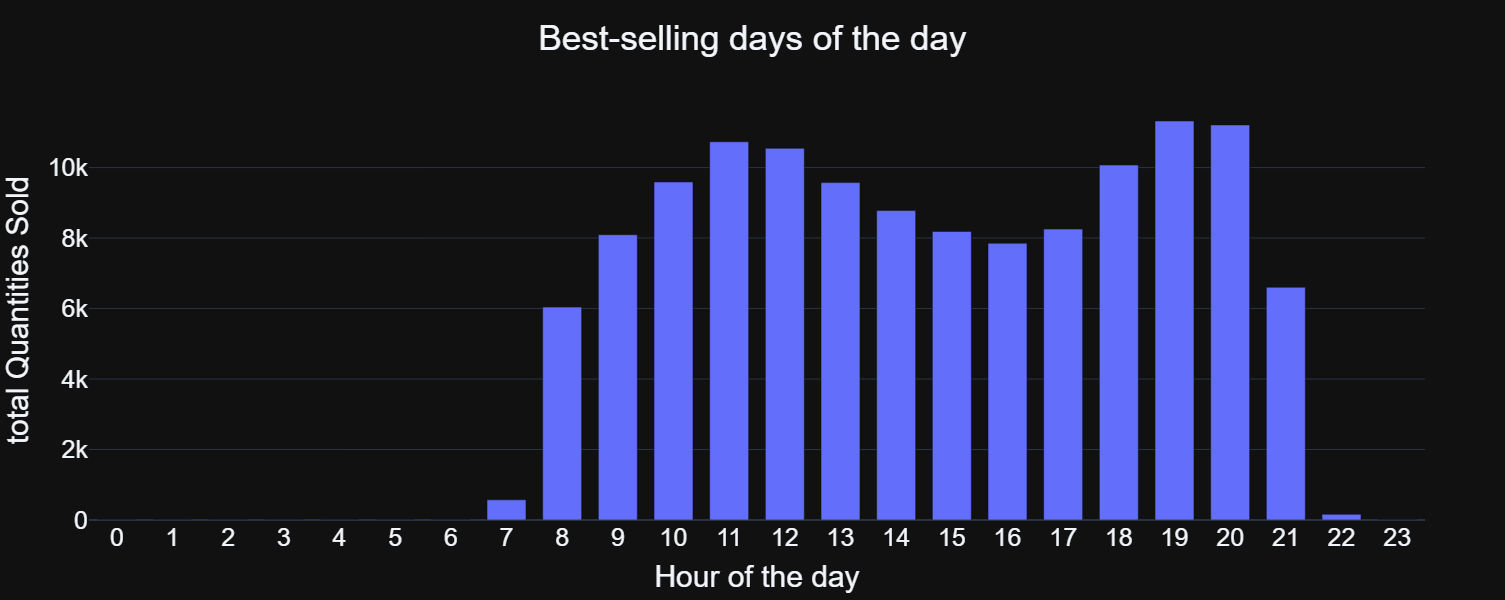

In [137]:
fig = px.bar(daily_summary, width=1500, height=600, template='plotly_dark', title='Best-selling hours of the day',
            x='Hour', y='total_Sales', labels={'Hour':'Hour of the day', 'total_Sales': 'total Quantities Sold'} )

fig.update_layout(
    title_x=0.5,         
    coloraxis_showscale=False, 
    font=dict(family="Arial", size=25),
    xaxis=dict(type='category'), bargap=0.3
)

fig.update_xaxes(dtick=1)
fig.show()

In [191]:
peak_hour = daily_summary['total_Sales'].idxmax()
Recession_hours = list(daily_summary[daily_summary['total_Sales'] < 2000]['Hour'])
print('peak hour: ', peak_hour)
print('Recession hours: ', Recession_hours)

# Sales drop significantly from 22:00 to 07:00 
# We highly recommend minimizing staff during this period 
# and utilizing these quiet hours for inventory management and shelf restocking

peak hour:  19
Recession hours:  [0, 1, 2, 3, 4, 5, 6, 7, 22, 23]


# Finding the peak day

In [243]:
Sales_daily

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.00,3.670,3.40,32.40,7.0,0.0,0.0,2.00,2014,1,248,Thursday
1,1/3/2014,8.00,4.000,4.40,50.60,16.0,0.0,20.0,4.00,2014,1,276,Friday
2,1/4/2014,2.00,1.000,6.50,61.85,10.0,0.0,9.0,1.00,2014,1,276,Saturday
3,1/5/2014,4.00,3.000,7.00,41.10,8.0,0.0,3.0,0.00,2014,1,276,Sunday
4,1/6/2014,5.00,1.000,4.50,21.70,16.0,2.0,6.0,2.00,2014,1,276,Monday
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2101,10/4/2019,7.34,5.683,2.25,22.45,13.0,0.0,1.0,1.00,2019,10,276,Friday
2102,10/5/2019,3.84,5.010,6.00,25.40,7.0,0.0,0.0,0.33,2019,10,276,Saturday
2103,10/6/2019,4.00,11.690,2.00,34.60,6.0,0.0,5.0,4.20,2019,10,276,Sunday
2104,10/7/2019,7.34,4.507,3.00,50.80,6.0,0.0,10.0,1.00,2019,10,276,Monday


In [247]:
week_summary = Sales_daily[
    ['M01AB','M01AE','N02BA','N02BE','N05B','N05C','R03','R06','Weekday Name']
].groupby('Weekday Name').sum().sum(axis=1)

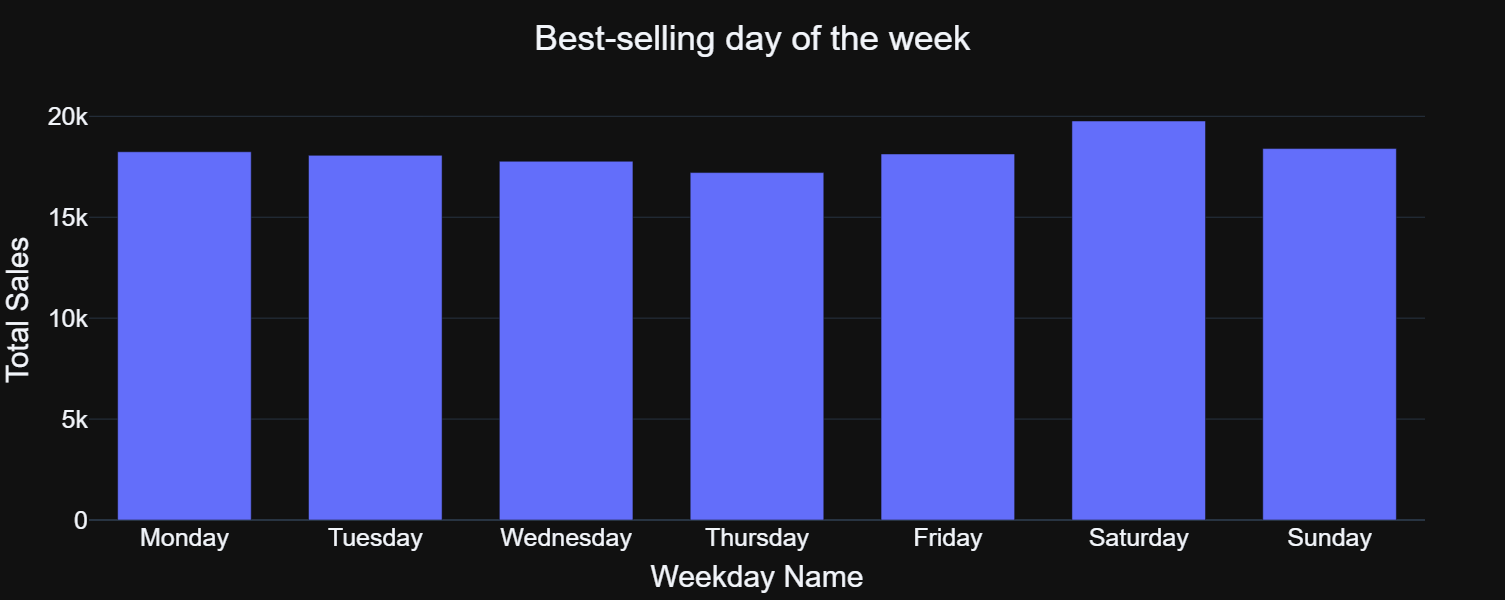

In [248]:
fig = px.bar(week_summary.reset_index(name='total_sales'), x='Weekday Name', y='total_sales',
             width=1000, height=600, template='plotly_dark',
             title='Best-selling day of the week', labels={'total_sales':'Total Sales'})

fig.update_layout(
    title_x=0.5,         
    coloraxis_showscale=False,
    font=dict(family="Arial", size=25),
    xaxis=dict(type='category'), bargap=0.3
)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig.update_xaxes(dtick=1, categoryorder='array', categoryarray=days_order)

fig.show()

In [249]:
peak_day = week_summary.idxmax()
print('Peak day: ', peak_day)

Peak day:  Saturday


# Finding the best-selling items of the month

In [250]:
data = Sales_monthly.iloc[:, 1:]
data

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
0,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.20
1,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.20
2,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.40
3,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.70
4,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.70
...,...,...,...,...,...,...,...,...
65,151.54,101.627,103.200,610.000,193.0,25.0,142.0,156.04
66,181.00,103.541,92.800,649.800,250.6,20.0,115.0,105.20
67,181.91,88.269,84.200,518.100,237.0,26.0,145.0,97.30
68,161.07,111.437,93.500,984.480,227.8,16.0,161.0,109.10


In [253]:
best_selling = data.sum().idxmax()
best_selling

'N02BE'

In [254]:
# Since N02BE (Paracetamol) is by far the highest-selling item, 
# the pharmacy must maintain a high safety stock level to prevent running out of supply. 
# Additionally, placing these high-turnover products near the front counter
# or register will streamline the dispensing process and minimize customer wait times